In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches 
import shutil

from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import rbf_kernel as rbf
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from scipy.special import gamma, kv
from time import perf_counter
from reml import NadarayaWatsonClassifier, DyadicNWC, LocalizedNWC

rng = np.random.default_rng(seed=None)

import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update(
    {
        'text.usetex': True
    }
)

In [2]:
CONFIG = {
    "data": {
        "num_train": 10000,
        "lipschitz_constant": 0.15
    },
    "kernel": {
        "bandwidth": 0.2
    },
    "evaluation": {
        "num_test": 10, 
        "acc_test": 500,
        "dyadic_m": 5, 
        "localized_k": 10
    }
}

In [3]:
# NOTE: AISTATS paper dimensions 
page_width_pt = 487.8225 
column_width_pt = 234.8775

def set_figure_size(width_pt, fraction=0.9, subplots=(1, 1), ratio=(5**0.5 - 1) / 2):
    fig_width_pt = width_pt * fraction
    inches_per_pt = 1 / 72.27

    fig_width_in = fig_width_pt * inches_per_pt
    fig_height_in = fig_width_in * ratio * (subplots[0] / subplots[1])

    return (fig_width_in, fig_height_in)

base_figure_size = set_figure_size(page_width_pt, 0.9, (1, 1))

In [4]:
def create_synthetic_data(num_samples, num_classes=2, gamma=3.0, feature_dim=2, centers=None):
    """
    Creates a synthetic dataset with well-separated classes.

    Args:
        num_samples (int): Total number of samples to generate.
        num_classes (int): Number of classes.
        gamma (float): The minimum separation distance between class centers.
        feature_dim (int): The dimensionality of the feature space.
        centers (list): Pre-defined class centers. If None, new centers will be generated.

    Returns:
        tuple: A tuple containing:
            - np.ndarray: The feature data (X).
            - np.ndarray: The corresponding labels (y).
            - list: The class centers used (for reuse in test set).
    """
    samples_per_class = num_samples // num_classes
    X = np.zeros((num_samples, feature_dim))
    y = np.zeros(num_samples, dtype='uint8')

    if centers is None:
        centers = []
        # Generate well-separated class centers
        while len(centers) < num_classes:
            # Generate a candidate center
            center_candidate = rng.uniform(-10, 10, feature_dim)
            # Check if it's far enough from existing centers
            if all(np.linalg.norm(center_candidate - c) >= gamma for c in centers):
                centers.append(center_candidate)

    # Generate data points for each class
    for i, center in enumerate(centers):
        start_idx = i * samples_per_class
        end_idx = (i + 1) * samples_per_class
        # Use a smaller covariance to keep clusters tight
        cov = [[0.5, 0], [0, 0.5]]
        X[start_idx:end_idx] = rng.multivariate_normal(center, cov, samples_per_class)
        y[start_idx:end_idx] = i

    return X, y, centers

def load_train_set(n_train, num_classes=3, gamma=3.0):
    x_train, y_train, centers = create_synthetic_data(n_train, num_classes, gamma)
    y_train_one_hot = np.zeros((n_train, num_classes))
    for i in range(n_train):
        y_train_one_hot[i, y_train[i]] = 1
    res = {'x_train': x_train, 'y_train': y_train, 'y_train_one_hot': y_train_one_hot, 'centers': centers}
    return res

def load_test_set(n_test, num_classes=3, gamma=3.0, centers=None):
    x_test, y_test, _ = create_synthetic_data(n_test, num_classes, gamma, centers=centers)
    res = {'x_test': x_test, 'y_test': y_test}
    return res


In [5]:
def K_epanechnikov(x, s: float = 1.):
    x = np.asarray(x)
    epanechnikov = np.where(x > 1., 1e-8, s * (1 - np.power(x, 2)))
    return epanechnikov

In [6]:
L = CONFIG['data']['lipschitz_constant']
lamda = CONFIG['kernel']['bandwidth']
num_train = CONFIG['data']['num_train']
num_test = CONFIG['evaluation']['num_test']
gamma = 1/L

In [7]:
dataset = load_train_set(num_train, 2, gamma)
X, y, y_onehot, _ = dataset.values()

scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

x_train, x_test, y_train, y_test = train_test_split(X_normalized, y_onehot, test_size=0.05)
print(f'Test set size: {x_test.shape[0]}')
num_test = min(num_test, x_test.shape[0])

Test set size: 500


In [8]:
n_random_samples = 100
random_indices = rng.choice(x_train.shape[0], n_random_samples, replace=False)
x_sample = x_train[random_indices]

distances = np.zeros((n_random_samples, n_random_samples))
for i in range(n_random_samples):
    for j in range(n_random_samples):
        distances[i, j] = np.linalg.norm(x_sample[i] - x_sample[j])

normalized_distances = distances / lamda

kernel_matrix = np.zeros((n_random_samples, n_random_samples))
for i in range(n_random_samples):
    for j in range(n_random_samples):
        if normalized_distances[i, j] < 1:
            kernel_matrix[i, j] = K_epanechnikov(normalized_distances[i, j])

In [9]:
nwc_predictions = []
nwc_probabilities = []
nwc_certainties = []


nwc = NadarayaWatsonClassifier(
    bandwidth=lamda, 
    lipschitz_constant=L, 
    ck=1.,
    kernel=K_epanechnikov
)

for i in range(num_test):
    probs, bounds = nwc.predict(x_test[i], x_train, y_train)
    predicted_class = np.argmax(probs)
    nwc_predictions.append(predicted_class)
    nwc_probabilities.append(probs)
    nwc_certainties.append(bounds)

print(f"Average bound over {num_test} samples: {np.mean(nwc_certainties)}")

Average bound over 10 samples: 0.05345453238102458


In [10]:
m = CONFIG['evaluation']['dyadic_m']

dyadic = DyadicNWC(m)
dyadic.fit(x_train, y_train)
dyadic_probabilities = dyadic.predict_proba(x_test)
dyadic_predictions = np.argmax(dyadic_probabilities, axis=1)

In [11]:
k = CONFIG['evaluation']['localized_k']

localized_nwc = LocalizedNWC(
    bandwidth=lamda, 
    lipschitz_constant=L, 
    kernel=K_epanechnikov
)

localized_predictions = []
localized_bounds = []
localized_probabilities = []

localized_nwc.fit(x_train, y_train)

for i in range(num_test):
    probs, bounds = localized_nwc.predict(x_test[i], k=k)
    localized_predictions.append(np.argmax(probs))
    localized_bounds.append(bounds)
    localized_probabilities.append(np.max(probs))    

In [12]:
lr_model = LogisticRegression().fit(x_train, np.argmax(y_train, axis=1))
lr_probabilities = lr_model.predict_proba(x_test)
lr_predictions = np.argmax(lr_probabilities, axis=1)

In [9]:
"""
CONDITIONAL MEAN EMBEDDINGS
"""

def power_func(meas, lambd, n, k, K, gamma):
    arg = np.exp(2.6)**2*rbf(meas, meas, gamma=gamma) - k@np.linalg.solve(K+n*lambd*np.eye(K.shape[0]), k.T)
    if arg < 0:
        print(f"Warning: negative argument {arg}, setting to 0")
        arg = 0.
    return np.sqrt(arg)

def context_conf_int(meas_train, meas_test, cont_train, K, lambd=1e-4, delta=0.05, rkhs_bound=1, gamma=1/((np.exp(7.5))**2)):
    k = np.exp(2.6)**2*rbf(meas_test, meas_train, gamma=gamma)
    prob = cont_train@np.linalg.solve(K + len(meas_train)*lambd*np.eye(len(meas_train)), k.T)
    prob = 1 / (1 + np.exp(-prob))
    val = np.max(prob)
    prob_cont = np.where(prob == np.amax(prob))[0][0]
    cg = 1/4*np.sqrt(np.log(np.linalg.det(K + np.max([1, len(meas_train)*lambd])*np.eye(len(meas_train)))) - 2*np.log(delta))
    epsilon = power_func(meas_test, lambd, len(meas_train), k, K, gamma=gamma)*(np.sqrt(rkhs_bound) + cg/np.sqrt(len(meas_train)*lambd))
    ret_unc = 0 
    if val < 0:
        ret_unc = val
    else:
        ret_unc = np.max([0, (val - epsilon)[0, 0]])
    return val, epsilon, prob_cont

In [20]:
cme_gamma = 1/((np.exp(2.0))**2)
K_cme = np.exp(2.6)**2 * rbf(x_train, x_train, gamma=cme_gamma)
print("Computed the kernel matrix.")

cme_predictions = []
cme_probabilities = []
cme_uncertainties = []

print(f"Running CME classification on {num_test} test samples...")

for i in range(num_test):
    print(f"CME Iteration: {i}")
    test_sample = x_test[i:i+1]  # Keep 2D shape
    val, epsilon, predicted_class = context_conf_int(
        x_train, test_sample, y_train.T, K_cme, gamma=cme_gamma
    )
    cme_predictions.append(predicted_class)
    cme_probabilities.append(val)
    cme_uncertainties.append(epsilon.item())

print(f"CME Classification completed.")
print(f"Average uncertainty over {num_test} samples: {np.mean(cme_uncertainties):.4f}")

Computed the kernel matrix.
Running CME classification on 10 test samples...
CME Iteration: 0
CME Iteration: 1
CME Iteration: 2
CME Iteration: 3
CME Iteration: 4
CME Iteration: 5
CME Iteration: 6
CME Iteration: 7
CME Iteration: 8
CME Iteration: 9
CME Classification completed.
Average uncertainty over 10 samples: 0.0526


# Test Sample Plots

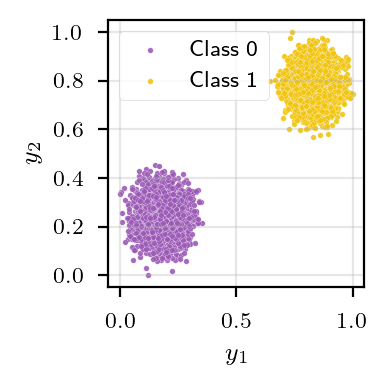

In [18]:
# plt.figure()

# # Use viridis colormap for the scatter plot
# scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.6, s=4)

# plt.xlabel('Feature 1')
# plt.ylabel('Feature 2')
# # plt.title('Synthetic 2-Class Dataset')
# plt.colorbar(scatter, label='Class')
# plt.grid(True, alpha=0.3)
# # plt.xlim(-11, 11)
# # plt.ylim(-11, 11)
# plt.tight_layout()
# plt.savefig('results/dataset.pgf', bbox_inches='tight')
# plt.show()

# Scatter plot of the dataset colored by class
plt.figure(figsize=set_figure_size(page_width_pt, 0.3, ratio=1.))

# Normalize the x and y axes to be between 0 and 1
x_min, x_max = X[:, 0].min(), X[:, 0].max()
y_min, y_max = X[:, 1].min(), X[:, 1].max()

X_normalized = np.copy(X)
X_normalized[:, 0] = (X[:, 0] - x_min) / (x_max - x_min)
X_normalized[:, 1] = (X[:, 1] - y_min) / (y_max - y_min)

# Create boolean mask for each class
class_0_mask = (y == 0)
class_1_mask = (y == 1)

# Plot each class separately with distinct colors
plt.scatter(X_normalized[class_0_mask, 0], X_normalized[class_0_mask, 1], c='#9b59b6', 
           alpha=0.9, s=4, edgecolors='white', linewidth=0.1, label='Class 0')
plt.scatter(X_normalized[class_1_mask, 0], X_normalized[class_1_mask, 1], c='#f1c40f', 
           alpha=0.9, s=4, edgecolors='white', linewidth=0.1, label='Class 1')

plt.xlabel(r'$y_1$')
plt.ylabel(r'$y_2$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/synthetic/margin_points_normalized.pdf', bbox_inches='tight')
plt.show()


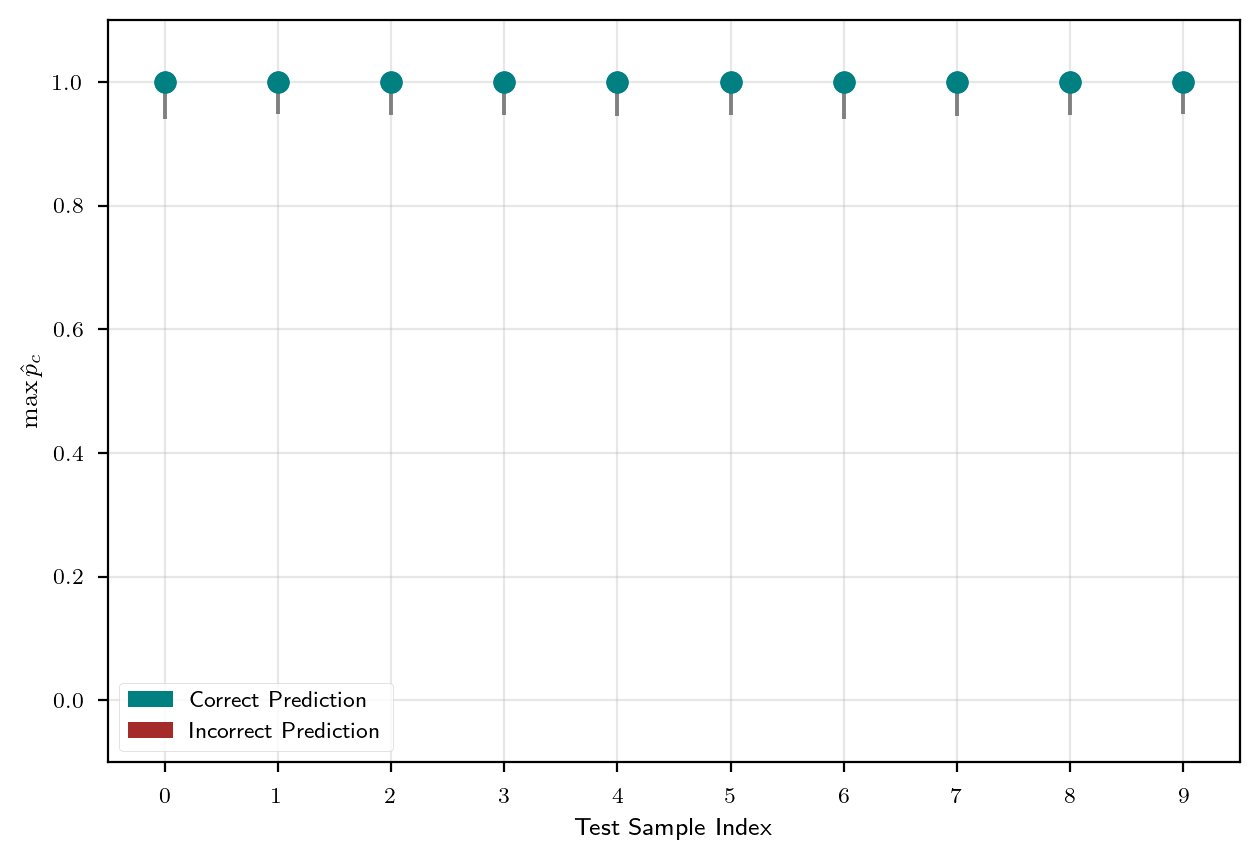

In [22]:
plt.figure()

max_probs = [np.max(prob) for prob in nwc_probabilities]
x_indices = np.arange(len(max_probs))

# Create colors based on prediction correctness
colors = ['teal' if pred == np.argmax(y_test[i]) else 'brown' 
          for i, pred in enumerate(nwc_predictions)]

lower_errors = [min(cert, prob) for cert, prob in zip(nwc_certainties, max_probs)]
upper_errors = [min(cert, 1.0 - prob) for cert, prob in zip(nwc_certainties, max_probs)]  

plt.errorbar(x_indices, max_probs, yerr=[lower_errors, upper_errors], fmt='o', capsize=5, 
             markersize=8, ecolor='gray')

# Color the markers
for i, (x, y, color) in enumerate(zip(x_indices, max_probs, colors)):
    plt.scatter(x, y, c=color, s=60, zorder=5)

# Create legend handles for correct and incorrect predictions
legend_elements = [patches.Patch(facecolor='teal', label='Correct Prediction'), patches.Patch(facecolor='brown', label='Incorrect Prediction')]

plt.xlabel('Test Sample Index')
plt.ylabel(r'$\max \hat{p}_c$')
# plt.title('Regular NWC: Maximum Probability with Certainty Bounds')
plt.grid(True, alpha=0.3)
plt.ylim(-0.1, 1.1)
plt.xlim(-0.5, len(max_probs) - 0.5)
plt.xticks(x_indices)
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('results/regular_nwc.pgf', bbox_inches='tight')
plt.show()


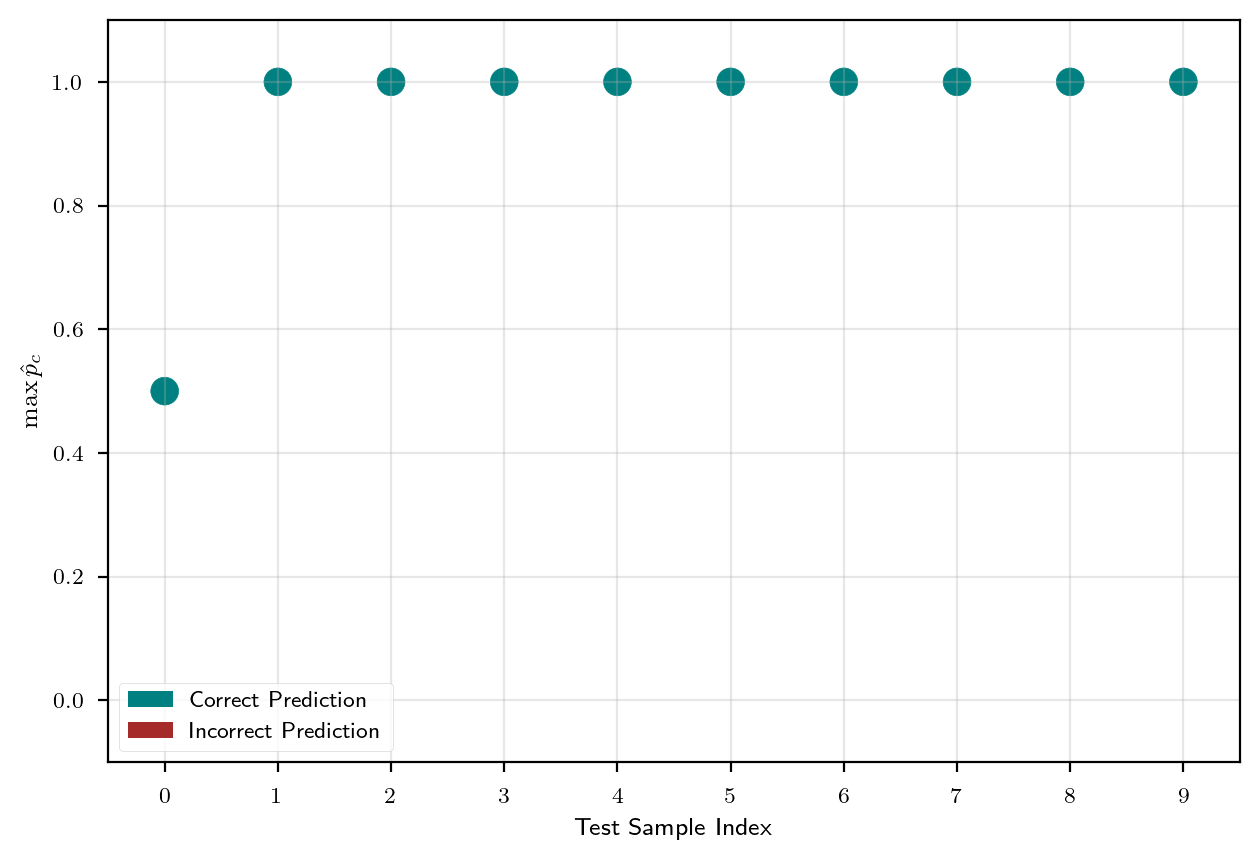

In [23]:
plt.figure()

dyadic_max_probs = [np.max(prob) for prob in dyadic_probabilities[:num_test]]
x_indices = np.arange(len(dyadic_max_probs))

# Create colors based on prediction correctness
colors = ['teal' if pred == np.argmax(y_test[i]) else 'brown' 
          for i, pred in enumerate(dyadic_predictions[:num_test])]

plt.scatter(x_indices, dyadic_max_probs, c=colors, s=100, alpha=1.0)

# Create legend handles for correct and incorrect predictions
legend_elements = [patches.Patch(facecolor='teal', label='Correct Prediction'), patches.Patch(facecolor='brown', label='Incorrect Prediction')]

plt.xlabel('Test Sample Index')
plt.ylabel(r'$\max \hat{p}_c$')
# plt.title('Dyadic NWC: Maximum Probability Predictions')
plt.grid(True, alpha=0.3)
plt.ylim(-0.1, 1.1)
plt.xlim(-0.5, len(dyadic_max_probs) - 0.5)
plt.xticks(x_indices)
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('results/dyadic_nwc.pgf', bbox_inches='tight')
plt.show()


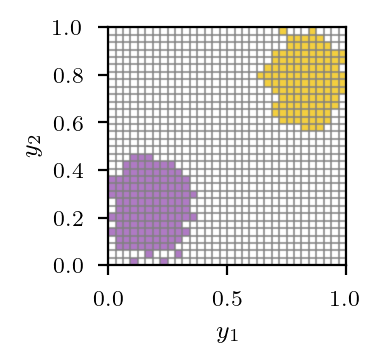

In [17]:
plt.figure(figsize=set_figure_size(width_pt=page_width_pt, fraction=0.3, ratio=1.))

# Define colors for the classes
bg_colors = ['#9b59b6', '#f1c40f']  # Purple and yellow

# --- Top plot: Decision regions with grid ---
for cube_idx, data in dyadic.tree.items():
    # Determine the predicted class for this cube
    predicted_class = np.argmax(data['label_sum'])
    
    # Calculate the cube's boundaries
    divisions = 2**dyadic.m
    x_start = cube_idx[0] / divisions
    y_start = cube_idx[1] / divisions
    width = 1 / divisions
    
    # Draw the rectangle with the color of the predicted class
    rect = patches.Rectangle(
        (x_start, y_start), width, width,
        linewidth=0.5, edgecolor='none', facecolor=bg_colors[predicted_class], alpha=0.8
    )
    plt.gca().add_patch(rect)

# Draw the grid lines
divisions = 2**dyadic.m
for i in range(divisions + 1):
    pos = i / divisions
    plt.axhline(pos, color='gray', linestyle='-', linewidth=0.8, alpha=0.7)
    plt.axvline(pos, color='gray', linestyle='-', linewidth=0.8, alpha=0.7)

# plt.title(f'Dyadic NWC Decision Regions (m={dyadic.m})')
plt.xlabel(r'$y_1$')
plt.ylabel(r'$y_2$')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('results/dyadic_cells.pdf', bbox_inches='tight')
plt.show()


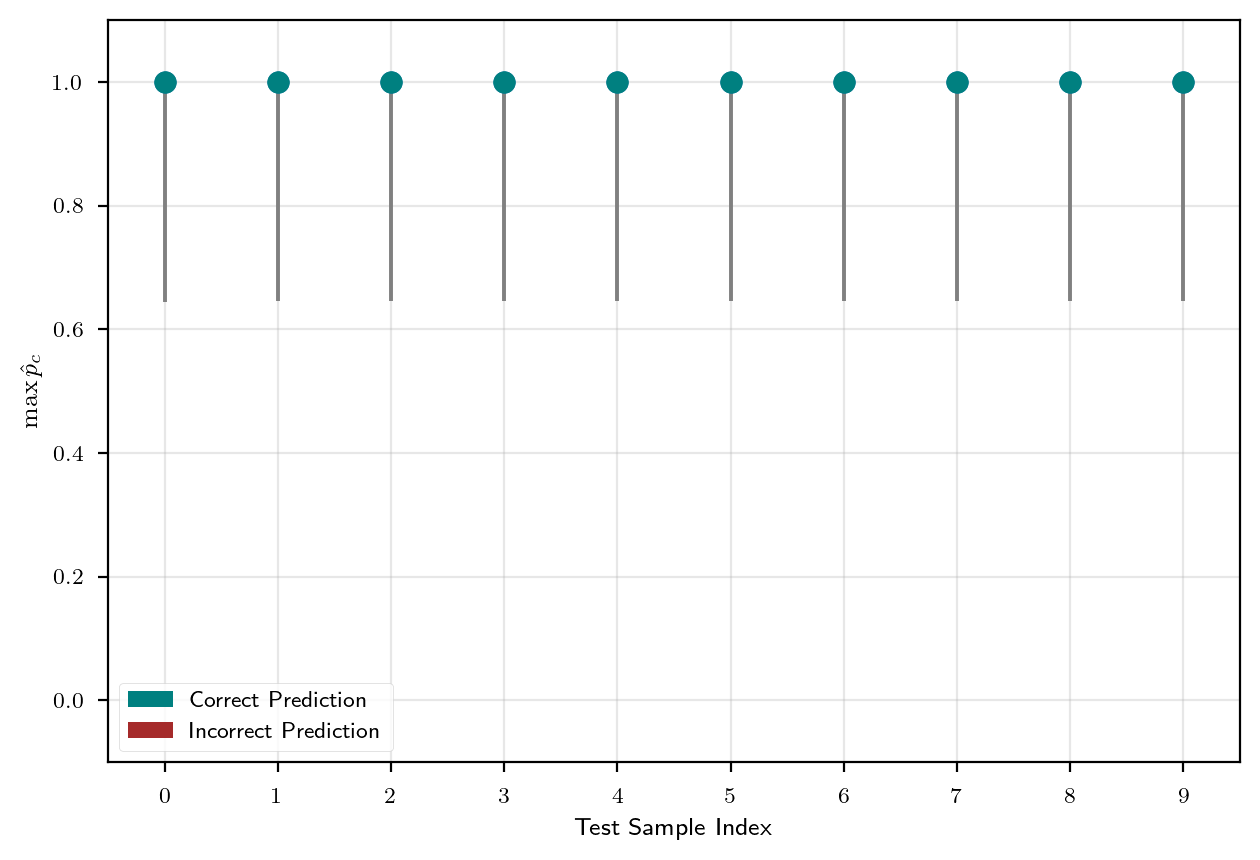

In [25]:
plt.figure()

localized_max_probs = [np.max(prob) for prob in localized_probabilities]
x_indices = np.arange(len(localized_max_probs))

# Create colors based on prediction correctness
colors = ['teal' if pred == np.argmax(y_test[i]) else 'brown' 
          for i, pred in enumerate(localized_predictions)]

# Fix negative values by ensuring bounds are properly capped
lower_errors = [min(cert, prob) for cert, prob in zip(localized_bounds, localized_max_probs)]
upper_errors = [max(0, min(cert, 1.0 - prob)) for cert, prob in zip(localized_bounds, localized_max_probs)]

plt.errorbar(x_indices, localized_max_probs, yerr=[lower_errors, upper_errors], fmt='o', capsize=5, markersize=8, ecolor='gray')

# Color the markers
for i, (x, y, color) in enumerate(zip(x_indices, localized_max_probs, colors)):
    plt.scatter(x, y, c=color, s=60, zorder=5)

# Create legend handles for correct and incorrect predictions
legend_elements = [patches.Patch(facecolor='teal', label='Correct Prediction'), patches.Patch(facecolor='brown', label='Incorrect Prediction')]

plt.xlabel('Test Sample Index')
plt.ylabel(r'$\max \hat{p}_c$')
# plt.title('Localized NWC: Maximum Probability with Certainty Bounds')
plt.grid(True, alpha=0.3)
plt.ylim(-0.1, 1.1)
plt.xlim(-0.5, len(localized_max_probs) - 0.5)
plt.xticks(x_indices)
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('results/localized_nwc.pgf', bbox_inches='tight')
plt.show()

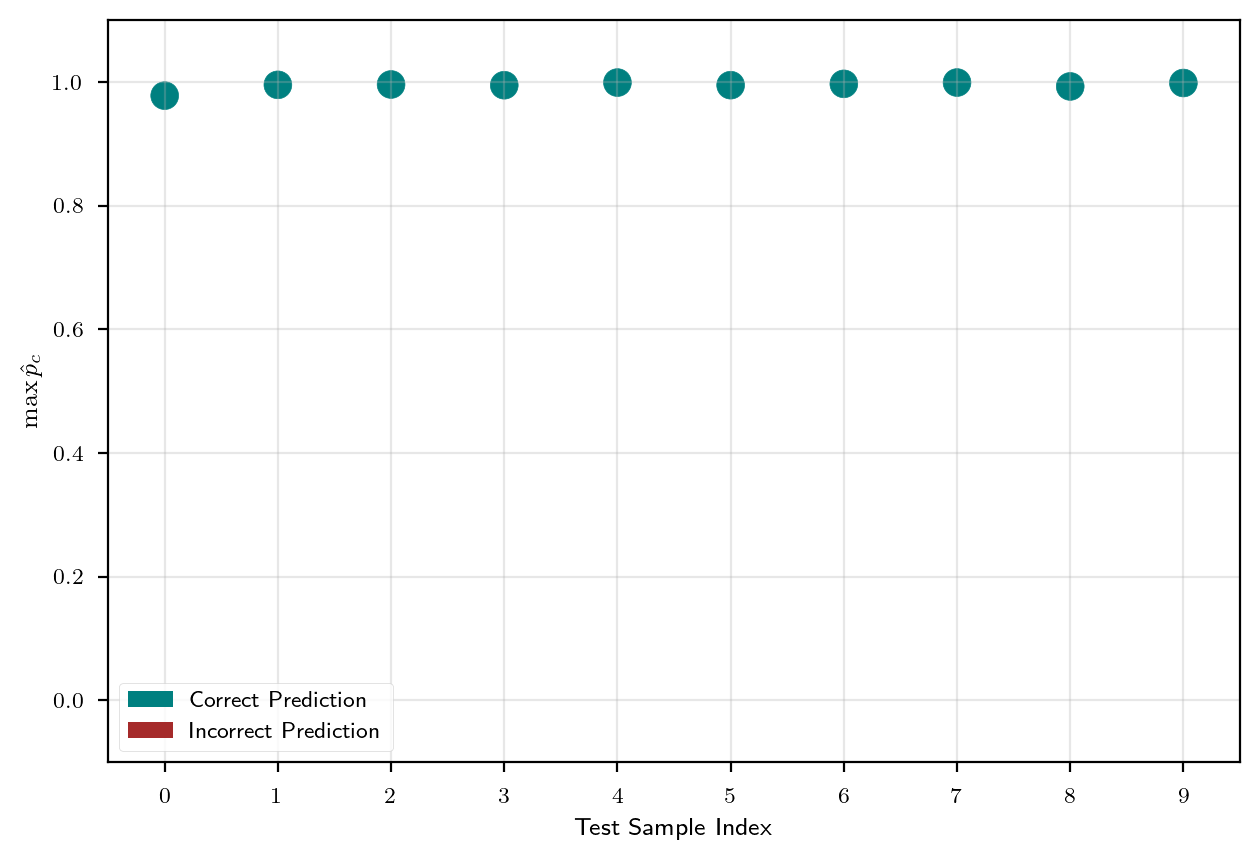

In [26]:
plt.figure()

lr_max_probs = [np.max(prob) for prob in lr_probabilities[:num_test]]
x_indices = np.arange(len(lr_max_probs))

# Create colors based on prediction correctness
colors = ['teal' if pred == np.argmax(y_test[i]) else 'brown' 
          for i, pred in enumerate(lr_predictions[:num_test])]

plt.scatter(x_indices, lr_max_probs, c=colors, s=100, alpha=1.0)

# Create legend handles for correct and incorrect predictions
legend_elements = [patches.Patch(facecolor='teal', label='Correct Prediction'), patches.Patch(facecolor='brown', label='Incorrect Prediction')]

plt.xlabel('Test Sample Index')
plt.ylabel(r'$\max \hat{p}_c$')
# plt.title('Logistic Regression: Maximum Probability Predictions')
plt.grid(True, alpha=0.3)
plt.ylim(-0.1, 1.1)
plt.xlim(-0.5, len(lr_max_probs) - 0.5)
plt.xticks(x_indices)
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('results/logistic_regression.pgf', bbox_inches='tight')
plt.show()


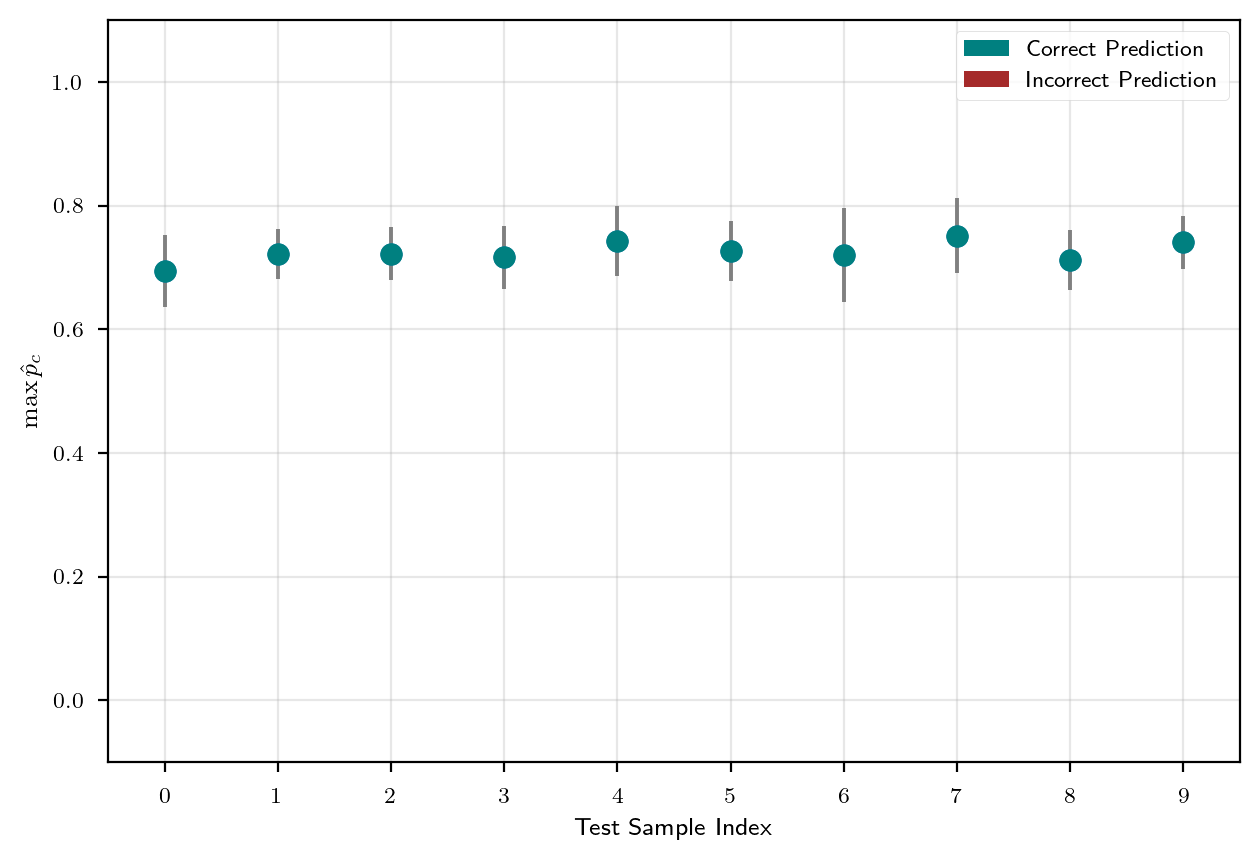

In [27]:
plt.figure()

cme_max_probs = [np.max(prob) for prob in cme_probabilities]
x_indices = np.arange(len(cme_max_probs))

# Create colors based on prediction correctness
colors = ['teal' if pred == np.argmax(y_test[i]) else 'brown' for i, pred in enumerate(cme_predictions)]

lower_errors = [min(cert, prob) for cert, prob in zip(cme_uncertainties, cme_max_probs)]
upper_errors = [max(0, min(cert, 1.0 - prob)) for cert, prob in zip(cme_uncertainties, cme_max_probs)]

plt.errorbar(x_indices, cme_max_probs, yerr=cme_uncertainties, fmt='o', capsize=5, markersize=8, ecolor='gray')

# Color the markers
for i, (x, y, color) in enumerate(zip(x_indices, cme_max_probs, colors)):
    plt.scatter(x, y, c=color, s=60, zorder=5)

# Create legend handles for correct and incorrect predictions
legend_elements = [patches.Patch(facecolor='teal', label='Correct Prediction'), patches.Patch(facecolor='brown', label='Incorrect Prediction')]

plt.xlabel('Test Sample Index')
plt.ylabel(r'$\max \hat{p}_c$')
# plt.title('CME: Maximum Probability with Uncertainty Bounds')
plt.grid(True, alpha=0.3)
plt.ylim(-0.1, 1.1)
plt.xlim(-0.5, len(cme_max_probs) - 0.5)
plt.xticks(x_indices)
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('results/cme.pgf', bbox_inches='tight')
plt.show()

# Accuracy and Runtime study

Change num_train and see how each method scales.

In [10]:
"""
TIMING AND ACCURACY STUDY WITH DETAILED METRICS
Comparing all 5 methods: Regular NWC, Dyadic NWC, Localized NWC, Logistic Regression, and CME
Including Precision, Recall, and F1 Score
"""

new_dataset = load_train_set(100000, 2, L)
X, y, y_onehot, _ = new_dataset.values()
scaler = MinMaxScaler()
x_normalized = scaler.fit_transform(X)

x_train, x_test, y_train, y_test = train_test_split(
    x_normalized, y_onehot, test_size=0.05
)

num_trains = [1000, 2000, 5000, 10000, 20000, 50000, 60000, 70000]
num_test = CONFIG['evaluation']['acc_test']

# Storage for results - Extended with precision, recall, F1
REGULAR_NWC_ACCURACIES = []
REGULAR_NWC_RUNTIMES = []
REGULAR_NWC_PRECISION = []
REGULAR_NWC_RECALL = []
REGULAR_NWC_F1 = []

DYADIC_NWC_ACCURACIES = []
DYADIC_NWC_FIT_TIMES = []
DYADIC_NWC_PREDICT_TIMES = []
DYADIC_NWC_PRECISION = []
DYADIC_NWC_RECALL = []
DYADIC_NWC_F1 = []

LOCALIZED_NWC_ACCURACIES = []
LOCALIZED_NWC_FIT_TIMES = []
LOCALIZED_NWC_PREDICT_TIMES = []
LOCALIZED_NWC_PRECISION = []
LOCALIZED_NWC_RECALL = []
LOCALIZED_NWC_F1 = []

LR_ACCURACIES = []
LR_FIT_TIMES = []
LR_PREDICT_TIMES = []
LR_PRECISION = []
LR_RECALL = []
LR_F1 = []

CME_ACCURACIES = []
CME_RUNTIMES = []
CME_PRECISION = []
CME_RECALL = []
CME_F1 = []

print("Starting comprehensive scaling study with detailed metrics...")
print("=" * 60)

for nt in num_trains:
    print(f"\nTraining with {nt} training samples...")
    
    # Randomly sample subset from existing training data
    indices = np.random.choice(len(x_train), size=nt, replace=False)
    x_train_current = x_train[indices]
    y_train_current = y_train[indices]
    
    # Use existing test set
    x_test_eval = x_test[:num_test]
    y_test_eval = y_test[:num_test]
    y_test_eval_labels = np.argmax(y_test_eval, axis=1)
    
    # 1. REGULAR NWC
    print("  Testing Regular NWC...")
    nwc_regular = NadarayaWatsonClassifier(
        bandwidth=lamda, 
        lipschitz_constant=L, 
        ck=1.,
        kernel=K_epanechnikov
    )
    
    t0 = perf_counter()
    regular_predictions = []
    for i in range(num_test):
        probs, _ = nwc_regular.predict(x_test_eval[i], x_train_current, y_train_current)
        regular_predictions.append(np.argmax(probs))
    t1 = perf_counter()
    
    regular_predictions = np.array(regular_predictions)
    regular_accuracy = np.mean(regular_predictions == y_test_eval_labels) * 100
    regular_runtime = t1 - t0
    
    # Calculate precision, recall, F1
    precision, recall, f1, _ = precision_recall_fscore_support(y_test_eval_labels, regular_predictions, average='weighted', zero_division=0)
    
    REGULAR_NWC_ACCURACIES.append(regular_accuracy)
    REGULAR_NWC_RUNTIMES.append(regular_runtime)
    REGULAR_NWC_PRECISION.append(precision)
    REGULAR_NWC_RECALL.append(recall)
    REGULAR_NWC_F1.append(f1)
    
    print(f"    Accuracy: {regular_accuracy:.1f}%, Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}, Runtime: {regular_runtime:.3f}s")
    
    # 2. DYADIC NWC
    print("  Testing Dyadic NWC...")
    dyadic_current = DyadicNWC(CONFIG['evaluation']['dyadic_m'])
    
    t0 = perf_counter()
    dyadic_current.fit(x_train_current, y_train_current)
    t1 = perf_counter()
    dyadic_fit_time = t1 - t0
    
    t0 = perf_counter()
    dyadic_probs = dyadic_current.predict_proba(x_test_eval)
    dyadic_predictions = np.argmax(dyadic_probs, axis=1)
    t1 = perf_counter()
    dyadic_predict_time = t1 - t0
    
    dyadic_accuracy = np.mean(dyadic_predictions == y_test_eval_labels) * 100
    precision, recall, f1, _ = precision_recall_fscore_support(y_test_eval_labels, dyadic_predictions, average='weighted', zero_division=0)
    
    DYADIC_NWC_ACCURACIES.append(dyadic_accuracy)
    DYADIC_NWC_FIT_TIMES.append(dyadic_fit_time)
    DYADIC_NWC_PREDICT_TIMES.append(dyadic_predict_time)
    DYADIC_NWC_PRECISION.append(precision)
    DYADIC_NWC_RECALL.append(recall)
    DYADIC_NWC_F1.append(f1)
    
    print(f"    Accuracy: {dyadic_accuracy:.1f}%, Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}")
    print(f"    Fit: {dyadic_fit_time:.3f}s, Predict: {dyadic_predict_time:.3f}s")
    
    # 3. LOCALIZED NWC
    print("  Testing Localized NWC...")
    localized_current = LocalizedNWC(
        bandwidth=lamda, 
        lipschitz_constant=L, 
        kernel=K_epanechnikov
    )
    
    t0 = perf_counter()
    localized_current.fit(x_train_current, y_train_current)
    t1 = perf_counter()
    localized_fit_time = t1 - t0
    
    t0 = perf_counter()
    localized_predictions = []
    for i in range(num_test):
        probs, _ = localized_current.predict(x_test_eval[i], k=CONFIG['evaluation']['localized_k'])
        localized_predictions.append(np.argmax(probs))
    t1 = perf_counter()
    localized_predict_time = t1 - t0
    
    localized_predictions = np.array(localized_predictions)
    localized_accuracy = np.mean(localized_predictions == y_test_eval_labels) * 100
    precision, recall, f1, _ = precision_recall_fscore_support(y_test_eval_labels, localized_predictions, average='weighted', zero_division=0)
    
    LOCALIZED_NWC_ACCURACIES.append(localized_accuracy)
    LOCALIZED_NWC_FIT_TIMES.append(localized_fit_time)
    LOCALIZED_NWC_PREDICT_TIMES.append(localized_predict_time)
    LOCALIZED_NWC_PRECISION.append(precision)
    LOCALIZED_NWC_RECALL.append(recall)
    LOCALIZED_NWC_F1.append(f1)
    
    print(f"    Accuracy: {localized_accuracy:.1f}%, Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}")
    print(f"    Fit: {localized_fit_time:.3f}s, Predict: {localized_predict_time:.3f}s")
    
    # 4. LOGISTIC REGRESSION
    print("  Testing Logistic Regression...")
    
    t0 = perf_counter()
    lr_current = LogisticRegression(random_state=42).fit(x_train_current, np.argmax(y_train_current, axis=1))
    t1 = perf_counter()
    lr_fit_time = t1 - t0
    
    t0 = perf_counter()
    lr_probs = lr_current.predict_proba(x_test_eval)
    lr_predictions = np.argmax(lr_probs, axis=1)
    t1 = perf_counter()
    lr_predict_time = t1 - t0
    
    lr_accuracy = np.mean(lr_predictions == y_test_eval_labels) * 100
    precision, recall, f1, _ = precision_recall_fscore_support(y_test_eval_labels, lr_predictions, average='weighted', zero_division=0)
    
    LR_ACCURACIES.append(lr_accuracy)
    LR_FIT_TIMES.append(lr_fit_time)
    LR_PREDICT_TIMES.append(lr_predict_time)
    LR_PRECISION.append(precision)
    LR_RECALL.append(recall)
    LR_F1.append(f1)
    
    print(f"    Accuracy: {lr_accuracy:.1f}%, Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}")
    print(f"    Fit: {lr_fit_time:.3f}s, Predict: {lr_predict_time:.3f}s")
    
    # 5. CONDITIONAL MEAN EMBEDDINGS
    print("  Testing CME...")
    if nt <= 10000:
        cme_gamma_current = 1/((np.exp(2.0))**2)
        
        t0 = perf_counter()
        K_cme_current = np.exp(2.6)**2 * rbf(x_train_current, x_train_current, gamma=cme_gamma_current)
        
        # Test on only 50 samples and extrapolate
        cme_test_size = min(50, num_test)
        cme_predictions_current = []
        for i in range(cme_test_size):
            print(f"CME Iteration: {i}")
            test_sample = x_test_eval[i:i+1]
            val, epsilon, predicted_class = context_conf_int(
                x_train_current, test_sample, y_train_current.T, K_cme_current, gamma=cme_gamma_current
            )
            cme_predictions_current.append(predicted_class)
        t1 = perf_counter()

        # Extrapolate runtime for full test set
        cme_runtime_per_sample = (t1 - t0) / cme_test_size
        cme_runtime = cme_runtime_per_sample * num_test

        cme_predictions_current = np.array(cme_predictions_current)
        cme_accuracy = np.mean(cme_predictions_current == y_test_eval_labels[:cme_test_size]) * 100
        precision, recall, f1, _ = precision_recall_fscore_support(y_test_eval_labels[:cme_test_size], cme_predictions_current, average='weighted', zero_division=0)
        
        CME_ACCURACIES.append(cme_accuracy)
        CME_RUNTIMES.append(cme_runtime)
        CME_PRECISION.append(precision)
        CME_RECALL.append(recall)
        CME_F1.append(f1)
        
        print(f"    Accuracy: {cme_accuracy:.1f}% (tested on {cme_test_size} samples), Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}")
        print(f"    Extrapolated Runtime: {cme_runtime:.3f}s")
                
    else:
        print("    Skipping CME (training set too large)")

print("\n" + "=" * 60)
print("Comprehensive scaling study completed!")

Starting comprehensive scaling study with detailed metrics...

Training with 1000 training samples...
  Testing Regular NWC...
    Accuracy: 100.0%, Precision: 1.000, Recall: 1.000, F1: 1.000, Runtime: 0.017s
  Testing Dyadic NWC...
    Accuracy: 97.8%, Precision: 0.979, Recall: 0.978, F1: 0.978
    Fit: 0.002s, Predict: 0.004s
  Testing Localized NWC...
    Accuracy: 100.0%, Precision: 1.000, Recall: 1.000, F1: 1.000
    Fit: 0.000s, Predict: 0.033s
  Testing Logistic Regression...
    Accuracy: 100.0%, Precision: 1.000, Recall: 1.000, F1: 1.000
    Fit: 0.001s, Predict: 0.000s
  Testing CME...
CME Iteration: 0
CME Iteration: 1
CME Iteration: 2
CME Iteration: 3
CME Iteration: 4
CME Iteration: 5
CME Iteration: 6
CME Iteration: 7
CME Iteration: 8
CME Iteration: 9
CME Iteration: 10
CME Iteration: 11
CME Iteration: 12
CME Iteration: 13
CME Iteration: 14
CME Iteration: 15
CME Iteration: 16
CME Iteration: 17
CME Iteration: 18
CME Iteration: 19
CME Iteration: 20
CME Iteration: 21
CME Iterati

# Results and Plots 

Save results as csv files and save plots as pgf files. 

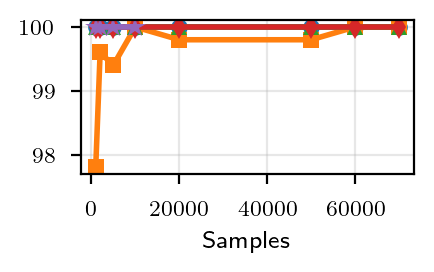

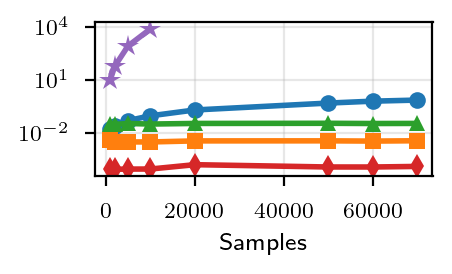

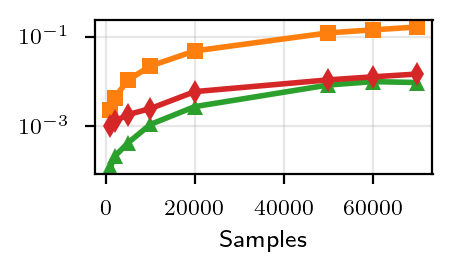

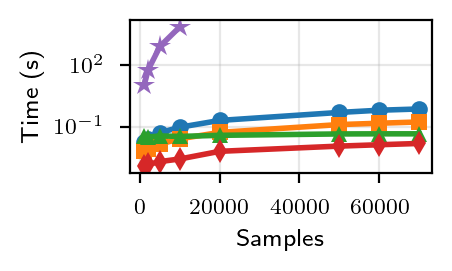

In [11]:
"""
INDIVIDUAL PLOTS FOR SCALING STUDY RESULTS
Creating separate plots for accuracy, runtime, fit time, and total time
"""

import matplotlib as mpl
from matplotlib.lines import Line2D

# (1) Use a colorblind friendly theme (tableau-colorblind10)
color_cycle = mpl.colormaps['tab10'].colors
method_colors = {
    'Regular NWC': color_cycle[0],      # blue
    'Dyadic NWC': color_cycle[1],       # orange
    'Localized NWC': color_cycle[2],    # green
    'Logistic Regression': color_cycle[3], # red
    'CME': color_cycle[4],              # purple
}

# (2) Helper for external legend subfigure
def save_legend_figure(labels, colors, filename, markers, linestyles):
    fig_legend = plt.figure(figsize=(4, 0.7))
    handles = [
        Line2D([0], [0], color=colors[l], marker=markers[l], linestyle=linestyles[l], linewidth=2, markersize=8, label=l)
        for l in labels
    ]
    fig_legend.legend(handles=handles, loc='center', ncol=len(labels), frameon=False)
    plt.axis('off')
    plt.tight_layout()
    fig_legend.savefig(filename, bbox_inches='tight')
    plt.close(fig_legend)

# Define plotting styles for each method
labels = ['Regular NWC', 'Dyadic NWC', 'Localized NWC', 'Logistic Regression', 'CME']
markers = {
    'Regular NWC': 'o',
    'Dyadic NWC': 's',
    'Localized NWC': '^',
    'Logistic Regression': 'd',
    'CME': '*',
}
linestyles = {
    'Regular NWC': '-',
    'Dyadic NWC': '-',
    'Localized NWC': '-',
    'Logistic Regression': '-',
    'CME': '-',
}

# Save external legend
save_legend_figure(
    labels=labels,
    colors=method_colors,
    filename='results/synthetic/legend_scaling_study.pdf',
    markers=markers,
    linestyles=linestyles
)

# Filter out None values for CME (for larger training sets where CME was skipped)
num_trains_cme = [nt for nt, acc in zip(num_trains, CME_ACCURACIES) if acc is not None]
cme_accuracies_filtered = [acc for acc in CME_ACCURACIES if acc is not None]
cme_runtimes_filtered = [rt for rt in CME_RUNTIMES if rt is not None]

# Set matplotlib backend for PGF output
plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "font.family": "sans-serif",
    "text.usetex": True,
    "pgf.rcfonts": False,
    "axes.prop_cycle": mpl.cycler(color=[method_colors[l] for l in labels])
})

# Plot 1: Accuracy Comparison
plt.figure(figsize=set_figure_size(page_width_pt, 0.35))
plt.plot(num_trains, REGULAR_NWC_ACCURACIES, marker=markers['Regular NWC'], label='Regular NWC', linewidth=2, markersize=6, color=method_colors['Regular NWC'])
plt.plot(num_trains, DYADIC_NWC_ACCURACIES, marker=markers['Dyadic NWC'], label='Dyadic NWC', linewidth=2, markersize=6, color=method_colors['Dyadic NWC'])
plt.plot(num_trains, LOCALIZED_NWC_ACCURACIES, marker=markers['Localized NWC'], label='Localized NWC', linewidth=2, markersize=6, color=method_colors['Localized NWC'])
plt.plot(num_trains, LR_ACCURACIES, marker=markers['Logistic Regression'], label='Logistic Regression', linewidth=2, markersize=6, color=method_colors['Logistic Regression'])
if cme_accuracies_filtered:
    plt.plot(num_trains_cme, cme_accuracies_filtered, marker=markers['CME'], label='CME', linewidth=2, markersize=8, color=method_colors['CME'])
plt.xlabel('Samples')
# plt.ylabel('Accuracy (\\%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/synthetic/margin_accuracy_vs_training_size.pgf', bbox_inches='tight')
plt.show()

# Plot 2: Runtime Comparison (Log scale)
plt.figure(figsize=set_figure_size(page_width_pt, 0.35))
plt.plot(num_trains, REGULAR_NWC_RUNTIMES, marker=markers['Regular NWC'], label='Regular NWC', linewidth=2, markersize=6)
plt.plot(num_trains, DYADIC_NWC_PREDICT_TIMES, marker=markers['Dyadic NWC'], label='Dyadic NWC', linewidth=2, markersize=6)
plt.plot(num_trains, LOCALIZED_NWC_PREDICT_TIMES, marker=markers['Localized NWC'], label='Localized NWC', linewidth=2, markersize=6)
plt.plot(num_trains, LR_PREDICT_TIMES, marker=markers['Logistic Regression'], label='Logistic Regression', linewidth=2, markersize=6)
if cme_runtimes_filtered:
    plt.plot(num_trains_cme, cme_runtimes_filtered, marker=markers['CME'], label='CME', linewidth=2, markersize=8)
plt.xlabel('Samples')
# plt.ylabel('Pred. Time (s)')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('results/synthetic/margin_runtime_vs_training_size.pgf', bbox_inches='tight')
plt.show()

# Plot 3: Fit/Training Times
plt.figure(figsize=set_figure_size(page_width_pt, 0.35))
plt.plot(num_trains, DYADIC_NWC_FIT_TIMES, marker=markers['Dyadic NWC'], label='Dyadic NWC', linewidth=2, markersize=6, color=method_colors['Dyadic NWC'])
plt.plot(num_trains, LOCALIZED_NWC_FIT_TIMES, marker=markers['Localized NWC'], label='Localized NWC', linewidth=2, markersize=6, color=method_colors['Localized NWC'])
plt.plot(num_trains, LR_FIT_TIMES, marker=markers['Logistic Regression'], label='Logistic Regression', linewidth=2, markersize=6, color=method_colors['Logistic Regression'])
plt.xlabel('Samples')
# plt.ylabel('Fit Time (s)')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/synthetic/margin_fit_time_vs_training_size.pgf', bbox_inches='tight')
plt.show()

# Plot 4: Total Time (Fit + Predict) vs Training Size
plt.figure(figsize=set_figure_size(page_width_pt, 0.35))
dyadic_total_times = [f + p for f, p in zip(DYADIC_NWC_FIT_TIMES, DYADIC_NWC_PREDICT_TIMES)]
localized_total_times = [f + p for f, p in zip(LOCALIZED_NWC_FIT_TIMES, LOCALIZED_NWC_PREDICT_TIMES)]
lr_total_times = [f + p for f, p in zip(LR_FIT_TIMES, LR_PREDICT_TIMES)]

plt.plot(num_trains, REGULAR_NWC_RUNTIMES, marker=markers['Regular NWC'], label='Regular NWC (predict only)', linewidth=2, markersize=6)
plt.plot(num_trains, dyadic_total_times, marker=markers['Dyadic NWC'], label='Dyadic NWC (fit + predict)', linewidth=2, markersize=6)
plt.plot(num_trains, localized_total_times, marker=markers['Localized NWC'], label='Localized NWC (fit + predict)', linewidth=2, markersize=6)
plt.plot(num_trains, lr_total_times, marker=markers['Logistic Regression'], label='Logistic Regression (fit + predict)', linewidth=2, markersize=6)
if cme_runtimes_filtered:
    plt.plot(num_trains_cme, cme_runtimes_filtered, marker=markers['CME'], label='CME (total)', linewidth=2, markersize=8)

plt.xlabel('Samples')
plt.ylabel('Time (s)')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('results/synthetic/margin_total_time_vs_training_size.pgf', bbox_inches='tight')
plt.show()

In [35]:
"""
SAVE ENHANCED RESULTS TO CSV FILES
"""

# Create comprehensive results dataframe with all metrics
results_df = pd.DataFrame({
    'num_train': num_trains,
    'regular_nwc_accuracy': REGULAR_NWC_ACCURACIES,
    'regular_nwc_precision': REGULAR_NWC_PRECISION,
    'regular_nwc_recall': REGULAR_NWC_RECALL,
    'regular_nwc_f1': REGULAR_NWC_F1,
    'regular_nwc_runtime': REGULAR_NWC_RUNTIMES,
    'dyadic_nwc_accuracy': DYADIC_NWC_ACCURACIES,
    'dyadic_nwc_precision': DYADIC_NWC_PRECISION,
    'dyadic_nwc_recall': DYADIC_NWC_RECALL,
    'dyadic_nwc_f1': DYADIC_NWC_F1,
    'dyadic_nwc_fit_time': DYADIC_NWC_FIT_TIMES,
    'dyadic_nwc_predict_time': DYADIC_NWC_PREDICT_TIMES,
    'localized_nwc_accuracy': LOCALIZED_NWC_ACCURACIES,
    'localized_nwc_precision': LOCALIZED_NWC_PRECISION,
    'localized_nwc_recall': LOCALIZED_NWC_RECALL,
    'localized_nwc_f1': LOCALIZED_NWC_F1,
    'localized_nwc_fit_time': LOCALIZED_NWC_FIT_TIMES,
    'localized_nwc_predict_time': LOCALIZED_NWC_PREDICT_TIMES,
    'lr_accuracy': LR_ACCURACIES,
    'lr_precision': LR_PRECISION,
    'lr_recall': LR_RECALL,
    'lr_f1': LR_F1,
    'lr_fit_time': LR_FIT_TIMES,
    'lr_predict_time': LR_PREDICT_TIMES
})

# Add CME results (pad with NaN for missing values)
def pad_list(lst, target_length):
    return lst + [np.nan] * (target_length - len(lst))

results_df['cme_accuracy'] = pad_list(CME_ACCURACIES, len(num_trains))
results_df['cme_precision'] = pad_list(CME_PRECISION, len(num_trains))
results_df['cme_recall'] = pad_list(CME_RECALL, len(num_trains))
results_df['cme_f1'] = pad_list(CME_F1, len(num_trains))
results_df['cme_runtime'] = pad_list(CME_RUNTIMES, len(num_trains))

# Save to CSV
results_df.to_csv('results/margin_comprehensive_results.csv', index=False)
print("Enhanced results saved to 'synthetic_comprehensive_results.csv'")

print("\nDataframe preview:")
print(results_df.head())

Enhanced results saved to 'synthetic_comprehensive_results.csv'

Dataframe preview:
   num_train  regular_nwc_accuracy  regular_nwc_precision  regular_nwc_recall  \
0       1000                 100.0                    1.0                 1.0   
1       2000                 100.0                    1.0                 1.0   
2       5000                 100.0                    1.0                 1.0   
3      10000                 100.0                    1.0                 1.0   
4      20000                 100.0                    1.0                 1.0   

   regular_nwc_f1  regular_nwc_runtime  dyadic_nwc_accuracy  \
0             1.0             0.015650                 98.4   
1             1.0             0.023145                 99.0   
2             1.0             0.047944                 99.6   
3             1.0             0.093041                 99.8   
4             1.0             0.183402                 99.8   

   dyadic_nwc_precision  dyadic_nwc_recall  dyadic